In [54]:
import pandas as pd
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

In [45]:
step_1 = pd.read_csv('./auto1_ds_challenge_data/auto1_ds_challenge_step1.csv')
step_2 = pd.read_csv('./auto1_ds_challenge_data/auto1_ds_challenge_step2.csv')
step_3 = pd.read_csv('./auto1_ds_challenge_data/auto1_ds_challenge_step3.csv')

In [46]:
step_1_2_left = step_1.merge(step_2,on='id',how='left').fillna(0)
step_1_2_left['step_1_kpi_factor'] = step_1_2_left.first_quote_wkda.apply(lambda x: 1 if x >0 else 0)

step_1_2_right = step_1.merge(step_2,on='id',how='right').fillna(0)
step_1_2_right['step_2_kpi_factor'] = step_1_2_right.actual_offer_accepted.apply(lambda x: 1 if x >0 else 0)



step_3['step_3_kpi_factor'] = step_3.sold_price.apply(lambda x: 1 if x>0 else 0)

In [47]:
## Task2a
# step_1_kpi: conversion rate of first touch point per n user
# num_user_entered_step_2_of_each_n_user_in_step_1 /n
# step_2_kpi: conversion rate of self estimation pre n user
# num_user_sold_the_car_of_each_n_user_in_step_2 /n
# step_3_kpi: rate of sold pre n user
# num_car_bought_by_merchant_of_each_n_car_in_step_3 /n

<AxesSubplot:>

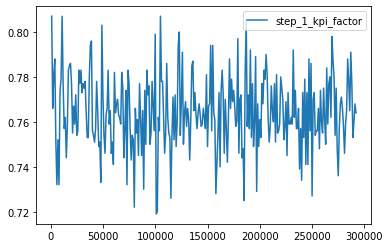

In [18]:
n = 1000
# Here we take the rolling windows with size n and get the row whose index%n == 0.
step_1_kpi = step_1_2_left[['step_1_kpi_factor']].rolling(n).mean()[n-1::n]
step_1_kpi.plot.line()

<AxesSubplot:>

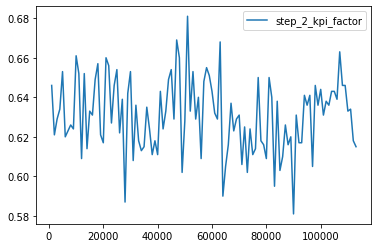

In [23]:
step_2_kpi = step_1_2_right[['step_2_kpi_factor']].rolling(n).mean()[n-1::n]
step_2_kpi.plot.line()

<AxesSubplot:>

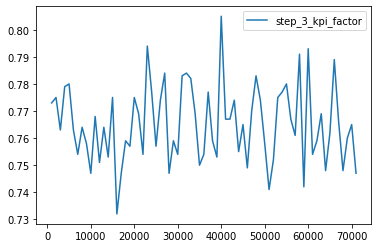

In [25]:
step_3_kpi = step_3[['step_3_kpi_factor']].rolling(n).mean()[n-1::n]
step_3_kpi.plot.line()

In [442]:
## task2b
step_1_2 = step_1.merge(step_2,on='id',how='right')
step_1_2['actual_offer_accepted'] = step_1_2.actual_offer_accepted.apply(lambda x: int(x))

step_2_3 = step_2.merge(step_3,on='id',how='right')
step_1_2_3 = step_1.merge(step_2_3,on='id',how='right')
step_1_2_3['actual_offer_accepted'] = step_1_2_3.actual_offer_accepted.apply(lambda x: int(x))


step_1_2_3['sold'] = step_1_2_3.sold_price.apply(lambda x: 1 if x>0 else 0)

In [444]:
## Task2b.
## In general I do not agree with my colleges's argument.
## I can split his reasoning into two parts, he said 'it will only benefit conversion without any drawbacks.'
## It means 1. increase first quote will benefit(increase) conversion 2. there is no drawbacks if we increase first quote.
## My answer to 1 is that sometimes if first quote is increaseing the conversion rate will be decreasing
## My answer to 2 is that when quote is increasing the draw back is that the sold rate will be decreasing.

<AxesSubplot:xlabel='avg_first_quote_wkda'>

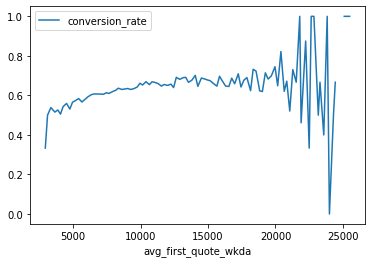

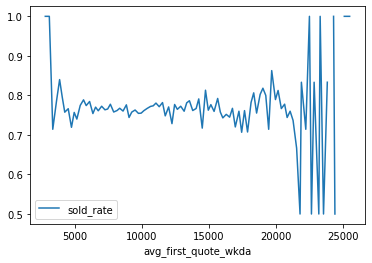

In [446]:
## Task2a.
# We address 1 and 2 as described above.
# we split first_quote_wkda into 100 bins and calculated the corresponding conversion rate and sold rate, 
# As we can see while first_quote_wkda increases, sometimes the rate of sold and conversion drops.


size = 100
bins = [el for el in range(size)]



step_1_2['bins'] = pd.cut(
    step_1_2.first_quote_wkda,
    size,
    labels=bins
)

plot_2a_1 = step_1_2[['bins','first_quote_wkda','actual_offer_accepted']]\
            .groupby('bins')\
            .agg(
                 avg_first_quote_wkda = ('first_quote_wkda', 'mean'),
                 conversion_rate = ('actual_offer_accepted', 'mean')
     
            )


plot_2a_1.plot.line(
    x='avg_first_quote_wkda',
    y='conversion_rate'
)



step_1_2_3['bins'] = pd.cut(
    step_1_2_3.first_quote_wkda,
    size,
    labels=bins
)

plot_2a_2 = step_1_2_3[['bins','first_quote_wkda','sold','actual_offer_accepted']]\
            .groupby('bins')\
            .agg(
                 avg_first_quote_wkda = ('first_quote_wkda', 'mean'),
                 sold_rate = ('sold','mean'),
                 conversion_rate = ('actual_offer_accepted', 'mean')
     
            )


plot_2a_2.plot.line(
    x='avg_first_quote_wkda',
    y='sold_rate'
)

<AxesSubplot:xlabel='estimated_price_3rd_party_provider', ylabel='first_quote_wkda'>

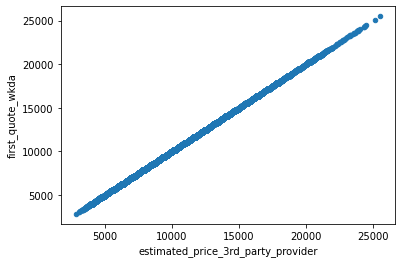

In [447]:
## Task2b.
# Now we build a xgboost model to analyze the driving force for conversion.

data_df = step1.merge(step2,on='id',how='right').dropna()
# We remove seleted columns with string type since they make the data to sparse after one-hot-encoding.
data_df = data_df.drop(columns=[
    'self_evaluation_completed_datetime',
    'wkda_created_on',
    'id',
    'main_type',
    'manufacturer'
])

num_cols = [
    'built_year',
    'mileage',
    'first_quote_wkda',
    'actual_offer',
    'number_of_owners',
    'estimated_price_3rd_party_provider'
]

cat_cols = [
    'damages_self_eval',
    'air_condition',
    'gearbox',
    'fueltype',
    'GPS'
]

# We will remove 'estimated_price_3rd_party_provider' since this does not represent the input of the customer. 
# It is more like a price_suggestion from third party, afterwards we somethow round it to get first_quote_wkda. 
# It is also highly correlated to first_quote_wkda. 
data_df.plot.scatter(x='estimated_price_3rd_party_provider',y='first_quote_wkda')

d:\pythonproject\hello_fresh_go_tasks\venv\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[02:18:34] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
train:---
              precision    recall  f1-score   support

       False       0.72      0.20      0.32     41433
        True       0.67      0.95      0.79     70543

    accuracy                           0.68    111976
   macro avg       0.70      0.58      0.55    111976
weighted avg       0.69      0.68      0.61    111976



<BarContainer object of 22 artists>

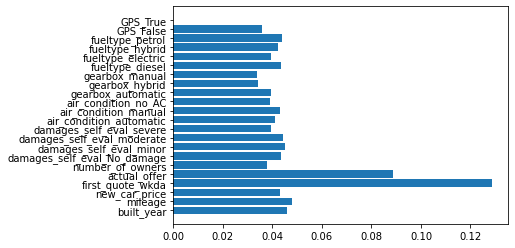

In [448]:
## Task2b.
# first_quote_wkda and actual_offer are the most importance features.
# We train and predict over the whole data set since we only want the model to figure out which features contribute the 
# most to conversion rather than test its prediction power.

data_df = pd.get_dummies(data_df, columns=cat_cols)
X= data_df.drop(columns=['actual_offer_accepted','estimated_price_3rd_party_provider'])
y = data_df['actual_offer_accepted']


def train_evaluate(model):
    
    model.fit(X, y)
    train_y_pred = model.predict(X)

    print('train:---')
    print(str(classification_report(y, train_y_pred)))
    

model = XGBClassifier()
train_evaluate(model)
plt.barh(X.columns, model.feature_importances_)

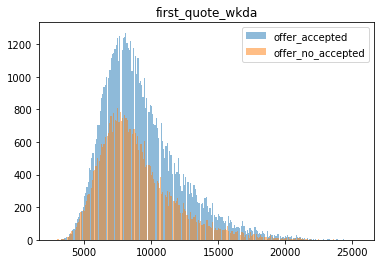

In [449]:
## Task2b.
# As we will see below it is quite hard to seperate offer_accepted and offer_not_accepted based on either first_quote_wkda
# or actual_offer

x = step_1_2[step_1_2.actual_offer_accepted==1].dropna().first_quote_wkda.values
y = step_1_2[step_1_2.actual_offer_accepted==0].dropna().first_quote_wkda.values

bins = 250
plt.title('first_quote_wkda')
plt.hist(x, bins, alpha=0.5, label='offer_accepted')
plt.hist(y, bins, alpha=0.5, label='offer_no_accepted')
plt.legend(loc='upper right')
plt.show()

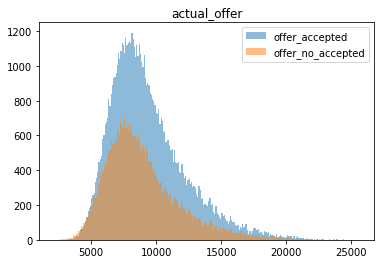

In [450]:
x = step_1_2[step_1_2.actual_offer_accepted==1].dropna().actual_offer.values
y = step_1_2[step_1_2.actual_offer_accepted==0].dropna().actual_offer.values

bins = 250
plt.title('actual_offer')
plt.hist(x, bins, alpha=0.5, label='offer_accepted')
plt.hist(y, bins, alpha=0.5, label='offer_no_accepted')
plt.legend(loc='upper right')
plt.show()

In [451]:
## Task2b.
# Even if we break down them by actual_offer there will always be false positive and false negative, i.e., 
# false positive: actual_offer < first_quote_wkda, but it is converted. In general, if a customr see that the final offer
# is less than the first_quote_wkda, then he shall not sell the car, but he sold it.
# false negative: actual_offer > first_quote_wkda, but it is not converted, in general if a customr see that the final offer
# is bigger then the first_quote_wkda, then he shall sell the car, but he did not.

actual_offer_values = sorted(new_step_1_2.actual_offer.values)
actual_offer_values_boundaries = [actual_offer_values[i] for i in range(0,len(actual_offer_values),len(actual_offer_values)//10)]

def get_actual_offer_value_level(actual_offer_value):
    for i in range(len(actual_offer_values_boundaries)-1):
        if actual_offer_value>=actual_offer_values_boundaries[i] and actual_offer_value<=actual_offer_values_boundaries[i+1]:
                return actual_offer_values_boundaries[i]
            
new_step_1_2 = step_1_2.copy().dropna()
new_step_1_2['diff_offer'] = new_step_1_2['actual_offer'] - new_step_1_2['first_quote_wkda']
new_step_1_2['sign'] = new_step_1_2['diff_offer'].apply(lambda x: 1 if x >=0 else 0)
new_step_1_2['actual_offer_value_level'] = new_step_1_2['actual_offer'].apply(lambda x: get_actual_offer_value_level(x))
new_step_1_2['diff_offer_absolut'] = abs(new_step_1_2['actual_offer'] - new_step_1_2['first_quote_wkda'])
new_step_1_2.groupby([ 'actual_offer_value_level','actual_offer_accepted','sign'])\
.agg(
    diff_offer_mean = ('diff_offer', 'mean'),
    diff_offer_std = ('diff_offer', 'std'),
    diff_offer_absolut_mean = ('diff_offer_absolut', 'mean'),
    diff_offer_absolut_std = ('diff_offer_absolut', 'std'),
    count = ('diff_offer', 'count')    
).reset_index()

,actual_offer_value_level,actual_offer_accepted,sign,diff_offer_mean,diff_offer_std,diff_offer_absolut_mean,diff_offer_absolut_std,count
0,2209.0,0,0,-289.698457,212.117444,289.698457,212.117444,3565
1,2209.0,0,1,205.570361,187.315227,205.570361,187.315227,1606
2,2209.0,1,0,-176.343762,149.211618,176.343762,149.211618,2525
3,2209.0,1,1,215.259903,175.336379,215.259903,175.336379,3509
4,6099.0,0,0,-227.748824,174.321573,227.748824,174.321573,2552
5,6099.0,0,1,206.200201,177.773251,206.200201,177.773251,1988
6,6099.0,1,0,-146.474856,128.570739,146.474856,128.570739,2426
7,6099.0,1,1,209.187397,169.832124,209.187397,169.832124,4237
8,6870.0,0,0,-201.269523,157.944078,201.269523,157.944078,2241
9,6870.0,0,1,204.576386,176.770709,204.576386,176.770709,2075


In [452]:
## Task2b.
# Therefore, the suggested price strategy is to look for the nearest converted neighbour regarding first_quote_wkda, i.e.,
# After received the estimated_price_3rd_party_provider we need to search for the nearest first_quote_wkda which previously
# has lead to a converted deal with the corresponding actual_offer price.
# for example we have table 
# {   
#     id: [1,2,3]
#     first_quote_wkda:[10,15,20],
#     actual_offer: [11,14,19],
#     offer_accepted: [False, True, False]
# }
# and the estimated_price_3rd_party_provider == 12,so our first_quote_wkda is 15 because it leads to a successful conversion
# and correspondingly our actual_offer is 14.
